Note: This requires https://github.com/joeloskarsson/weather-model-graphs/commit/c824c23036107967898c5b3471df36445bc90e4b#diff-72daea2494478edf48e319a44c42b839b9a6175a03dd1b2fa97ca8db212a79ca to be applied to the weather-model-graphs repository to have the mesh fit to the domain and have no mesh nodes far away from the slanted domain.

In [2]:
import xarray as xr
import json
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import weather_model_graphs as wmg
ds = xr.open_zarr("../test.zarr")

In [3]:
ds

<xarray.Dataset> Size: 9GB
Dimensions:                                                   (cell: 11792076,
                                                               time: 10)
Coordinates:
    clat                                                      (cell) float64 94MB dask.array<chunksize=(184252,), meta=np.ndarray>
    clon                                                      (cell) float64 94MB dask.array<chunksize=(184252,), meta=np.ndarray>
  * time                                                      (time) datetime64[ns] 80B ...
    x                                                         (cell) float64 94MB dask.array<chunksize=(184252,), meta=np.ndarray>
    y                                                         (cell) float64 94MB dask.array<chunksize=(184252,), meta=np.ndarray>
Dimensions without coordinates: cell
Data variables: (12/19)
    clct                                                      (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    lhfl_s                                                    (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    pres_sfc                                                  (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    qv_2m                                                     (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    rain_gsp_rate                                             (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    shfl_s                                                    (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    ...                                                        ...
    tot_prec                                                  (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    tqc_dia                                                   (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    tqi_dia                                                   (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    tqv_dia                                                   (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    u_10m                                                     (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
    v_10m                                                     (time, cell) float32 472MB dask.array<chunksize=(1, 11792076), meta=np.ndarray>
Attributes:
    CDI:                  Climate Data Interface version 1.8.3rc (http://mpim...
    Conventions:          CF-1.6
    comment:              Hauke Schulz (m300408) on l40224 (Linux 4.18.0-305....
    history:              /work/mh0010/m300408/DVC-test/icon-aes/bin/icon at ...
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    number_of_grid_used:  99
    references:           see MPIM/DWD publications
    source:               icon-nwp\tgit@gitlab.dkrz.de:icon/icon-nwp.git@7e23...
    title:                ICON simulation
    uuidOfHGrid:          3c7523ba-f78c-c23e-6654-012805ba3300

In [4]:
with open("domains_indices.json") as f:
    domains = json.load(f)
domain = domains["domain01"]

In [35]:
sel = ds.sel(cell=domain[::16**3])

In [36]:
sel

<xarray.Dataset> Size: 101kB
Dimensions:                                                   (cell: 128,
                                                               time: 10)
Coordinates:
    clat                                                      (cell) float64 1kB dask.array<chunksize=(128,), meta=np.ndarray>
    clon                                                      (cell) float64 1kB dask.array<chunksize=(128,), meta=np.ndarray>
  * time                                                      (time) datetime64[ns] 80B ...
    x                                                         (cell) float64 1kB dask.array<chunksize=(128,), meta=np.ndarray>
    y                                                         (cell) float64 1kB dask.array<chunksize=(128,), meta=np.ndarray>
Dimensions without coordinates: cell
Data variables: (12/19)
    clct                                                      (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    lhfl_s                                                    (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    pres_sfc                                                  (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    qv_2m                                                     (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    rain_gsp_rate                                             (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    shfl_s                                                    (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    ...                                                        ...
    tot_prec                                                  (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    tqc_dia                                                   (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    tqi_dia                                                   (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    tqv_dia                                                   (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    u_10m                                                     (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
    v_10m                                                     (time, cell) float32 5kB dask.array<chunksize=(1, 128), meta=np.ndarray>
Attributes:
    CDI:                  Climate Data Interface version 1.8.3rc (http://mpim...
    Conventions:          CF-1.6
    comment:              Hauke Schulz (m300408) on l40224 (Linux 4.18.0-305....
    history:              /work/mh0010/m300408/DVC-test/icon-aes/bin/icon at ...
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    number_of_grid_used:  99
    references:           see MPIM/DWD publications
    source:               icon-nwp\tgit@gitlab.dkrz.de:icon/icon-nwp.git@7e23...
    title:                ICON simulation
    uuidOfHGrid:          3c7523ba-f78c-c23e-6654-012805ba3300

In [37]:
coords = np.rad2deg(np.stack([sel.clon.data, sel.clat.data], axis=-1)).compute()
assert coords.shape == (len(sel.clat), 2), "Shape must be (n, 2)"

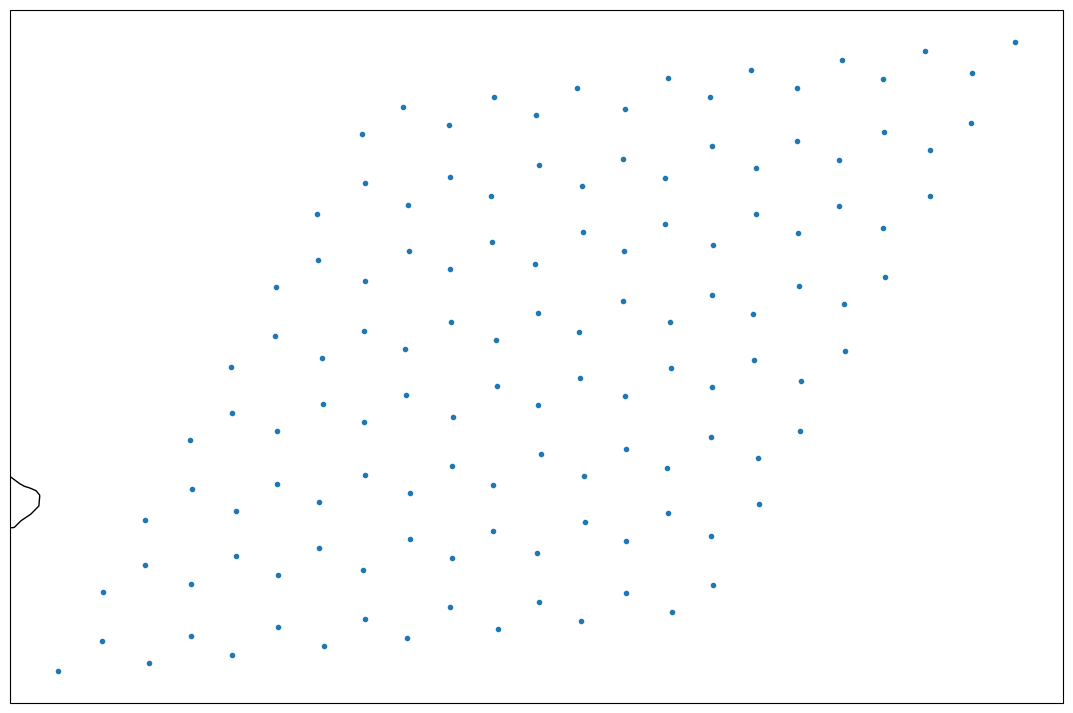

In [38]:
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": ccrs.PlateCarree()})
ax.scatter(coords[:, 0], coords[:, 1], marker=".")
ax.coastlines()

In [39]:
level_refinement_factor=3
mesh_node_distance=0.1
# Compute the size along x and y direction of area to cover with graph
# This is measured in the Cartesian coordiantes of xy
coord_extent = np.ptp(coords, axis=0)
print(coord_extent)
# Number of nodes that would fit on bottom level of hierarchy,
# in both directions
max_nodes_bottom = (coord_extent / mesh_node_distance).astype(int)
print(max_nodes_bottom)
# Find the number of mesh levels possible in x- and y-direction,
# and the number of leaf nodes that would correspond to
# max_nodes_bottom/(level_refinement_factor^mesh_levels) = 1
max_mesh_levels_float = np.log(max_nodes_bottom) / np.log(level_refinement_factor)
print(max_mesh_levels_float)

[3.07132305 2.02080913]
[30 20]
[3.09590327 2.72683303]


2025-03-23 16:50:15.934 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:94 - No `coords_crs` given: Assuming `coords` contains in-projection Cartesian coordinates.
2025-03-23 16:50:15.937 | DEBUG    | weather_model_graphs.create.mesh.mesh:create_multirange_2d_mesh_graphs:134 - mesh_levels: 2, nleaf: [27  9]


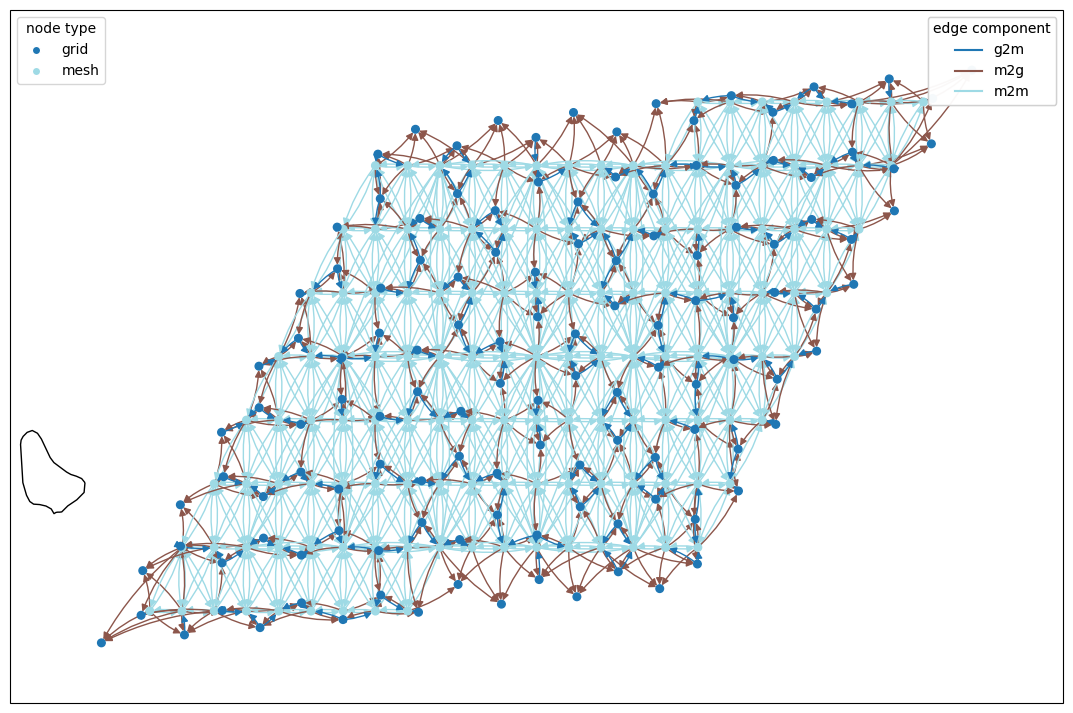

In [42]:


graph = wmg.create.archetype.create_graphcast_graph(coords, mesh_node_distance=mesh_node_distance, max_num_levels=3, level_refinement_factor=level_refinement_factor)
# graph = wmg.create.archetype.create_graphcast_graph(coords, mesh_node_distance=mesh_node_distance, max_num_levels=3, level_refinement_factor=level_refinement_factor)
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": ccrs.PlateCarree()})
wmg.visualise.nx_draw_with_pos_and_attr(
    graph, ax=ax, node_size=30, edge_color_attr="component", node_color_attr="type"
)
ax.coastlines()
# ax.set_extent([-60, -47, 9, 16.25])

In [10]:
# Define our projection
coords_crs = ccrs.PlateCarree()
graph_crs = ccrs.AzimuthalEquidistant(central_latitude=12.625, central_longitude=-53.5) # center of ICON 312m domain

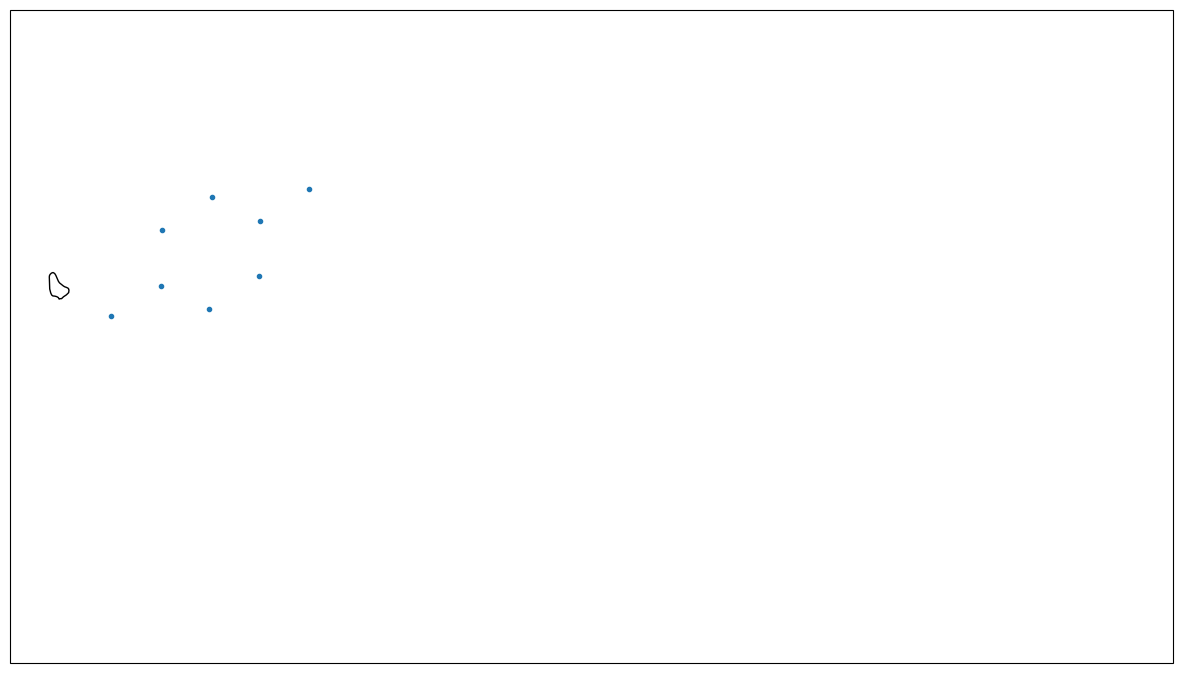

In [11]:
fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": graph_crs})
ax.scatter(coords[:, 0], coords[:, 1], marker=".", transform=ccrs.PlateCarree())
_ = ax.coastlines()
ax.set_extent([-60, -47, 9, 16.25])

In [ ]:
mesh_distance = (
    10**6
)  # Large euclidean distance in projection coordinates between mesh nodes
# graph = wmg.create.archetype.create_oskarsson_hierarchical_graph(coords, mesh_node_distance=mesh_node_distance,
#                                                                  max_num_levels=3, level_refinement_factor=level_refinement_factor,
#                                                                  coords_crs=coords_crs, graph_crs=graph_crs)
graph = wmg.create.archetype.create_graphcast_graph(coords, mesh_node_distance=mesh_node_distance, max_num_levels=3, level_refinement_factor=level_refinement_factor,
                                                                 coords_crs=coords_crs, graph_crs=graph_crs)
# fig, ax = plt.subplots(figsize=(15, 9), subplot_kw={"projection": graph_crs})
# wmg.visualise.nx_draw_with_pos_and_attr(
#     graph, ax=ax, node_size=30, edge_color_attr="component", node_color_attr="type"
# )
# _ = ax.coastlines()
# ax.set_extent([-60, -47, 9, 16.25])

NameError: name 'coords_crs' is not defined

In [1]:
graph_components

NameError: name 'graph_components' is not defined

In [35]:
wmg.split_graph_by_edge_attribute(graph=graph, attr='component')

{'m2g': <networkx.classes.digraph.DiGraph at 0x12d486ba0>,
 'g2m': <networkx.classes.digraph.DiGraph at 0x12d8e7a70>,
 'm2m': <networkx.classes.digraph.DiGraph at 0x12d6878c0>}

In [21]:
graph_components = wmg.split_graph_by_edge_attribute(graph=graph, attr='component')

In [22]:
# split the m2m graph into the different parts that create the up, in-level and down connections respectively
# this is how the graphs is stored in the neural-lam codebase
m2m_graph = graph_components.pop("m2m")
m2m_graph_components = wmg.split_graph_by_edge_attribute(
    graph=m2m_graph, attr="direction"
)
m2m_graph_components = {
    f"m2m_{name}": graph for name, graph in m2m_graph_components.items()
}
graph_components.update(m2m_graph_components)

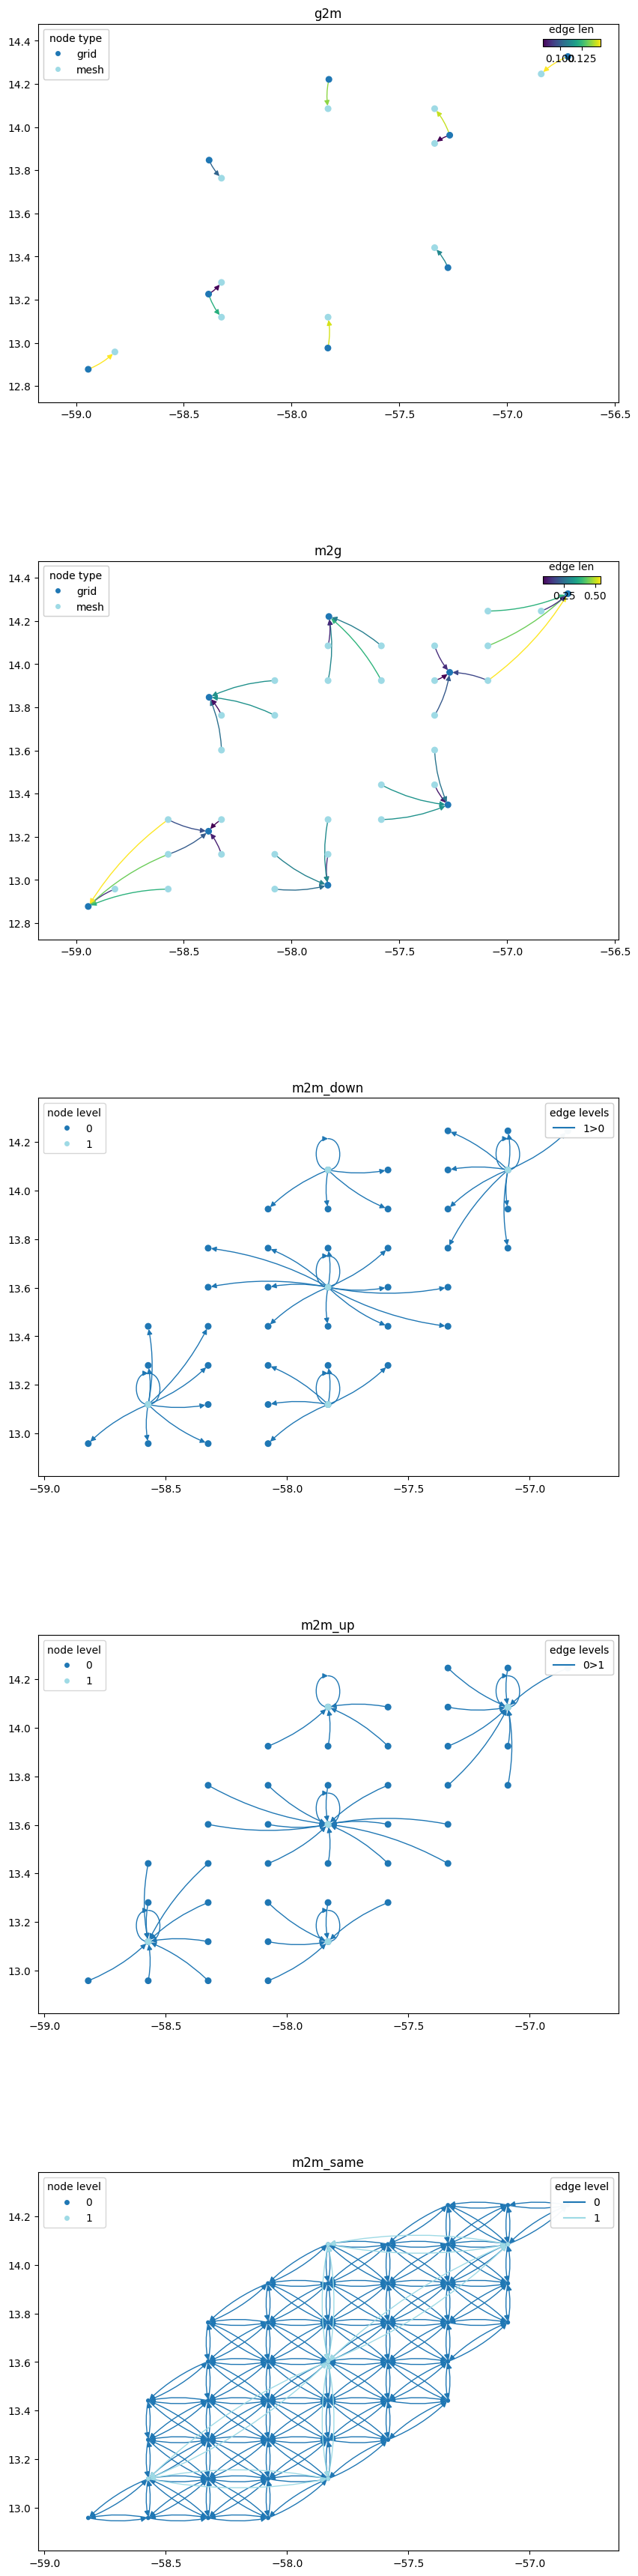

In [23]:
n_components = len(graph_components)
fig, axes = plt.subplots(nrows=n_components, ncols=1, figsize=(10, 9 * n_components))

for (name, graph), ax in zip(graph_components.items(), axes.flatten()):
    pl_kwargs = {}
    if name == "m2m_same":
        pl_kwargs = dict(edge_color_attr="level", node_color_attr="level", node_size=10)
    elif name == "g2m" or name == "m2g":
        pl_kwargs = dict(edge_color_attr="len", node_color_attr="type", node_size=30)
    elif name in ["m2m_up", "m2m_down"]:
        pl_kwargs = dict(
            edge_color_attr="levels", node_color_attr="level", node_size=30
        )

    wmg.visualise.nx_draw_with_pos_and_attr(graph, ax=ax, **pl_kwargs)
    ax.set_title(name)
    ax.set_aspect(1.0)

In [24]:
for component, graph in graph_components.items():
    wmg.save.to_pyg(graph=graph, name=component, output_directory="../data/graphs/graphcast/")

/Users/haukeschulz/Documents/GitProjects/mllam-exps-ShCu/.venv/lib/python3.12/site-packages/torch_geometric/utils/convert.py:249: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:278.)
  data[key] = torch.tensor(value)
2025-03-23 16:33:16.535 | INFO     | weather_model_graphs.save:to_pyg:139 - Saved edge index to ../data/graphs/graphcast/g2m_edge_index.pt and features ['len', 'vdiff'] to ../data/graphs/graphcast/g2m_features.pt.
2025-03-23 16:33:16.536 | INFO     | weather_model_graphs.save:to_pyg:146 - Saved node features ['pos'] to ../data/graphs/graphcast/g2m_node_features.pt.
2025-03-23 16:33:16.540 | INFO     | weather_model_graphs.save:to_pyg:139 - Saved edge index to ../data/graphs/graphcast/m2g_edge_index.pt and features ['len', 'vdiff'] t

In [43]:
hierarchical = False
graph_dir_path = "../data/graphs/graphcast/"
graph_components = wmg.split_graph_by_edge_attribute(graph=graph, attr='component')
for component, graph in graph_components.items():
    # This seems like a bit of a hack, maybe better if saving in wmg
    # was made consistent with nl
    if component == "m2m":
        if hierarchical:
            # Split by direction
            m2m_direction_comp = wmg.split_graph_by_edge_attribute(
                graph, attr="direction"
            )
            for direction, dir_graph in m2m_direction_comp.items():
                if direction == "same":
                    # Name just m2m to be consistent with non-hierarchical
                    wmg.save.to_pyg(
                        graph=dir_graph,
                        name="m2m",
                        list_from_attribute="level",
                        edge_features=["len", "vdiff"],
                        output_directory=graph_dir_path,
                    )
                else:
                    # up and down directions
                    wmg.save.to_pyg(
                        graph=dir_graph,
                        name=f"mesh_{direction}",
                        list_from_attribute="levels",
                        edge_features=["len", "vdiff"],
                        output_directory=graph_dir_path,
                    )
        else:
            wmg.save.to_pyg(
                graph=graph,
                name=component,
                list_from_attribute="dummy",  # Note: Needed to output list
                edge_features=["len", "vdiff"],
                output_directory=graph_dir_path,
            )
    else:
        wmg.save.to_pyg(
            graph=graph,
            name=component,
            edge_features=["len", "vdiff"],
            output_directory=graph_dir_path,
        )

2025-03-23 16:50:53.525 | INFO     | weather_model_graphs.save:to_pyg:139 - Saved edge index to ../data/graphs/graphcast/m2m_edge_index.pt and features ['len', 'vdiff'] to ../data/graphs/graphcast/m2m_features.pt.
2025-03-23 16:50:53.527 | INFO     | weather_model_graphs.save:to_pyg:146 - Saved node features ['pos'] to ../data/graphs/graphcast/m2m_node_features.pt.
2025-03-23 16:50:53.538 | INFO     | weather_model_graphs.save:to_pyg:139 - Saved edge index to ../data/graphs/graphcast/g2m_edge_index.pt and features ['len', 'vdiff'] to ../data/graphs/graphcast/g2m_features.pt.
2025-03-23 16:50:53.539 | INFO     | weather_model_graphs.save:to_pyg:146 - Saved node features ['pos'] to ../data/graphs/graphcast/g2m_node_features.pt.
2025-03-23 16:50:53.566 | INFO     | weather_model_graphs.save:to_pyg:139 - Saved edge index to ../data/graphs/graphcast/m2g_edge_index.pt and features ['len', 'vdiff'] to ../data/graphs/graphcast/m2g_features.pt.
2025-03-23 16:50:53.568 | INFO     | weather_model

In [16]:
G=graph_components['m2m']
edge_attrs = list(next(iter(G.edges(data=True)))[-1].keys())
print(edge_attrs)

['len', 'vdiff', 'level', 'direction', 'component']


In [17]:
for i, (_,_, feat_dict) in enumerate(G.edges(data=True)):
    print(feat_dict['len'], feat_dict['vdiff'])

0.34125811668888417 [-0.34125812  0.        ]
0.22453434751024126 [ 0.         -0.22453435]
0.40850064310585105 [-0.34125812 -0.22453435]
0.40850064310585105 [0.34125812 0.22453435]
0.34125811668888417 [-0.34125812  0.        ]
0.22453434751024126 [0.         0.22453435]
0.22453434751024126 [ 0.         -0.22453435]
0.40850064310585105 [-0.34125812 -0.22453435]
0.40850064310585105 [-0.34125812  0.22453435]
0.34125811668888417 [0.34125812 0.        ]
0.34125811668888417 [-0.34125812  0.        ]
0.22453434751024126 [0.         0.22453435]
0.22453434751024126 [ 0.         -0.22453435]
0.40850064310585105 [-0.34125812 -0.22453435]
0.40850064310585105 [-0.34125812  0.22453435]
0.40850064310585105 [ 0.34125812 -0.22453435]
0.34125811668888417 [-0.34125812  0.        ]
0.22453434751024126 [0.         0.22453435]
0.22453434751024304 [ 0.         -0.22453435]
0.40850064310585205 [-0.34125812 -0.22453435]
0.40850064310585105 [-0.34125812  0.22453435]
0.40850064310585205 [0.34125812 0.22453435]


In [45]:
set(feat_dict.keys())

{'component', 'direction', 'len', 'levels', 'vdiff'}

In [21]:
m2m_features = loads_file("m2m_features.pt")

In [22]:
for layer in m2m_features:
    break

In [24]:
layer[:,0]

tensor([0.3413, 0.4085, 0.4085, 0.3413, 0.3413, 0.2245, 0.4085, 0.2245, 0.3413,
        0.2245, 0.2245, 0.4085, 0.4085, 0.4085, 0.0000, 0.3413, 0.2245, 0.2245,
        0.4085, 0.4085, 0.2245, 0.3413, 0.2245, 0.4085, 0.4085, 0.4491, 0.3413,
        0.2245, 0.4085, 0.4085, 0.4085, 0.3413, 0.3413, 0.2245, 0.2245, 0.4085,
        0.4085, 0.4085, 0.3413, 0.3413, 0.3413, 0.2245, 0.2245, 0.4085, 0.4085,
        0.4085, 0.4085, 0.4085, 0.3413, 0.3413, 0.2245, 0.2245, 0.4085, 0.4085,
        0.4085, 0.5640, 0.3413, 0.2245, 0.2245, 0.4085, 0.4085, 0.4085, 0.6825,
        0.3413, 0.2245, 0.2245, 0.4085, 0.4085, 0.7185, 0.3413, 0.2245, 0.4085,
        0.4085, 0.7185, 0.3413, 0.3413, 0.2245, 0.4085, 0.4085, 0.4085, 0.3413,
        0.3413, 0.3413, 0.2245, 0.2245, 0.4085, 0.4085, 0.4085, 0.4085, 0.4085,
        0.3413, 0.3413, 0.2245, 0.2245, 0.4085, 0.4085, 0.4085, 0.4085, 0.4085,
        0.3413, 0.3413, 0.2245, 0.2245, 0.4085, 0.4085, 0.4085, 0.4085, 0.3413,
        0.3413, 0.3413, 0.2245, 0.2245, 

In [21]:
graph_components.items()

dict_items([('g2m', <networkx.classes.digraph.DiGraph object at 0x144c57b60>), ('m2m', <networkx.classes.digraph.DiGraph object at 0x144ebfda0>), ('m2g', <networkx.classes.digraph.DiGraph object at 0x144ebea50>)])

In [22]:
import torch
from torch_geometric.utils.convert import from_networkx

In [23]:
mesh_pos = from_networkx(graph_components['m2m']).pos.to(torch.float32)
# torch.save(mesh_pos, "../data/graph/graphcast/mesh_features.pt")

In [24]:
mesh_pos

tensor([[-58.8571,  12.9320],
        [-58.5158,  12.9320],
        [-58.5158,  13.6056],
        [-58.1746,  12.9320],
        [-58.1746,  13.6056],
        [-58.1746,  14.2792],
        [-57.8333,  12.9320],
        [-57.8333,  13.6056],
        [-57.8333,  14.2792],
        [-57.4921,  12.9320],
        [-57.4921,  13.6056],
        [-57.4921,  14.2792],
        [-57.1508,  13.6056],
        [-57.1508,  14.2792],
        [-56.8095,  14.2792]])

In [61]:
G=graph_components['m2m']

In [ ]:
from torch_geometric.utils.convert import from_networkx
from_networkx(graph_components['m2g']).edge_index.min(dim=1, keepdim=True)[0] >= 0

tensor(True)

In [34]:
m2g_min_indices = from_networkx(graph_components['m2g']).edge_index.min(dim=1, keepdim=True)[0]

In [35]:
m2g_min_indices[0] < m2g_min_indices[1]

tensor([True])

In [43]:
 from_networkx(graph_components['m2g']).edge_index.min(dim=1, keepdim=True)

torch.return_types.min(
values=tensor([[ 0],
        [45]]),
indices=tensor([[ 0],
        [82]]))

In [41]:
edge_index = from_networkx(graph_components['m2g']).edge_index
(edge_index - edge_index.min(dim=0, keepdim=True)[0]).min()

tensor(0)

In [19]:
    def loads_file(fn):
        return torch.load(
            os.path.join("../data/graphs/graphcast/", fn),
            map_location="cpu",
            weights_only=True,
        )

In [20]:
import torch
import os
m2g_edge_index = loads_file("m2g_edge_index.pt")

In [21]:
m2g_edge_index.max(dim=1, keepdim=True)[0][0]

AttributeError: 'list' object has no attribute 'max'